In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
from sklearn import metrics
import sklearn
import matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


folder_path = "/content/drive/MyDrive/AQuAdurationarea/"

Mounted at /content/drive


In [ ]:
Gq = pd.read_excel("/content/drive/MyDrive/AQuAdurationarea/i-lacco4.0 fiberphoto.xlsx", sheet_name='iCNODlongH')

In [ ]:
Cont = pd.read_excel("/content/drive/MyDrive/AQuAdurationarea/i-lacco4.0 fiberphoto.xlsx", sheet_name='iCNOnoDlongH')

In [ ]:
def idx_of_the_nearest(data, value):
  '''
  一番近いインデックスを取得
  '''
  idx = np.argmin(np.abs(np.array(data) - value))

  return idx

In [ ]:
def dFF_func(time, iso, green, BC_start_sec, BC_end_sec, BL_start_sec, BL_end_sec, fitting, mouse):
    '''
    dF/Fを算出する関数
    fitting: 1だったら470でfitting, 0だったら405でfitting
    '''
    BC_start = idx_of_the_nearest(time, BC_start_sec)
    BC_end = idx_of_the_nearest(time, BC_end_sec)

    BL_start = idx_of_the_nearest(time, BL_start_sec)
    BL_end = idx_of_the_nearest(time, BL_end_sec)


    add1 = [1 for i in range(len(green))]

    fit = np.polyfit(time, iso, 1)
    fittedIso = fit[0] * np.array(time) + fit[1]
    isoBC = iso - fittedIso
    isoBCN = isoBC + add1

    fit = np.polyfit(time[BC_start:BC_end], green[BC_start:BC_end], 1)
    fittedGreen = fit[0] * np.array(time) + fit[1]

    if fitting == 1:
        greenBC = green - fittedGreen
        greenBCN = greenBC + add1

    else:
        greenBC = green - fittedIso
        greenBCN = greenBC + add1

    BL_mean = np.mean(greenBCN[BL_start:BL_end] / isoBCN[BL_start:BL_end])
    dFF = greenBCN / isoBCN - BL_mean

    fig_func(time, iso, green, fittedIso, fittedGreen, isoBCN, greenBCN, dFF, BC_start, BC_end, BL_start, BL_end, fitting, mouse)

    return dFF

In [ ]:
def fig_func(time, iso, green, fittedIso, fittedGeen, isoBCN, greenBCN, dFF, BC_start, BC_end, BL_start, BL_end, fitting, mouse):

    plt.figure(figsize=(50, 2))
    plt.subplots_adjust(wspace=0.1, hspace=0.1)

    #plt.subplot(1, 3, 1)
    #plt.plot(time, iso, color="gray")
    #plt.plot(time, green, color="black")

    if fitting == 1:
        plt.plot(time[BC_start:BC_end], green[BC_start:BC_end], color="red")
        plt.plot(time, fittedIso, color="blue")

    if fitting == 1:
        plt.plot(time, fittedGeen, color="blue")
    else:
        plt.plot(time, fittedIso, color="blue")


    #plt.subplot(1, 3, 2)
    #plt.plot(time, isoBCN, color="gray")
    #plt.plot(time, greenBCN, color="black")

    plt.subplot(1, 3, 3)
    plt.plot(time, dFF, color="green")
    plt.plot(time[BL_start:BL_end], dFF[BL_start:BL_end], color='red')

    plt.title('{}'.format(mouse))

In [ ]:
time_ = [float(_) for _ in np.array(Gq.filter(like=('Time'), axis=1))][10:-9]

/tmp/ipykernel_5633/1811052165.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  time_ = [float(_) for _ in np.array(Gq.filter(like=('Time'), axis=1))][10:-9]


In [ ]:
Cont1_CNO = np.array(Cont.filter(['i-lacco1_CNO_iso', 'i-lacco1_CNO_green']))[10:-9]
Cont2_CNO = np.array(Cont.filter(['i-lacco2_CNO_iso', 'i-lacco2_CNO_green']))[10:-9]
Cont3_CNO = np.array(Cont.filter(['i-lacco3_CNO_iso', 'i-lacco3_CNO_green']))[10:-9]
Cont4_CNO = np.array(Cont.filter(['i-lacco4_CNO_iso', 'i-lacco4_CNO_green']))[10:-9]
Cont5_CNO = np.array(Cont.filter(['i-lacco5_CNO_iso', 'i-lacco5_CNO_green']))[10:-9]
Cont6_CNO = np.array(Cont.filter(['i-lacco6_CNO_iso', 'i-lacco6_CNO_green']))[10:-9]
Cont7_CNO = np.array(Cont.filter(['i-lacco7_CNO_iso', 'i-lacco7_CNO_green']))[10:-9]
Cont8_CNO = np.array(Cont.filter(['i-lacco8_CNO_iso', 'i-lacco8_CNO_green']))[10:-9]
Cont9_CNO = np.array(Cont.filter(['i-lacco9_CNO_iso', 'i-lacco9_CNO_green']))[10:-9]
Cont10_CNO = np.array(Cont.filter(['i-lacco10_CNO_iso', 'i-lacco10_CNO_green']))[10:-9]

In [ ]:
hM3Dq1_CNO = np.array(Gq.filter(['i-lacco1_CNO_iso', 'i-lacco1_CNO_green']))[10:-9]
hM3Dq2_CNO = np.array(Gq.filter(['i-lacco2_CNO_iso', 'i-lacco2_CNO_green']))[10:-9]
hM3Dq3_CNO = np.array(Gq.filter(['i-lacco3_CNO_iso', 'i-lacco3_CNO_green']))[10:-9]
hM3Dq4_CNO = np.array(Gq.filter(['i-lacco4_CNO_iso', 'i-lacco4_CNO_green']))[10:-9]
hM3Dq5_CNO = np.array(Gq.filter(['i-lacco5_CNO_iso', 'i-lacco5_CNO_green']))[10:-9]
hM3Dq6_CNO = np.array(Gq.filter(['i-lacco6_CNO_iso', 'i-lacco6_CNO_green']))[10:-9]
hM3Dq7_CNO = np.array(Gq.filter(['i-lacco7_CNO_iso', 'i-lacco7_CNO_green']))[10:-9]
hM3Dq8_CNO = np.array(Gq.filter(['i-lacco8_CNO_iso', 'i-lacco8_CNO_green']))[10:-9]
hM3Dq9_CNO = np.array(Gq.filter(['i-lacco9_CNO_iso', 'i-lacco9_CNO_green']))[10:-9]

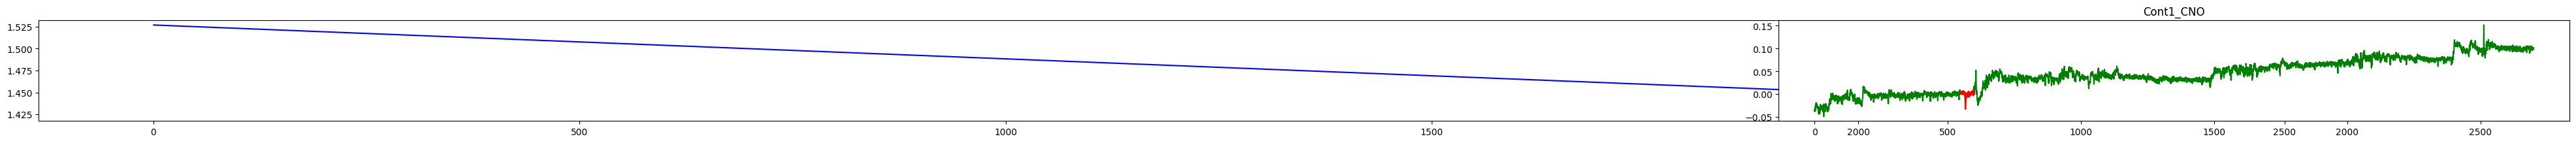

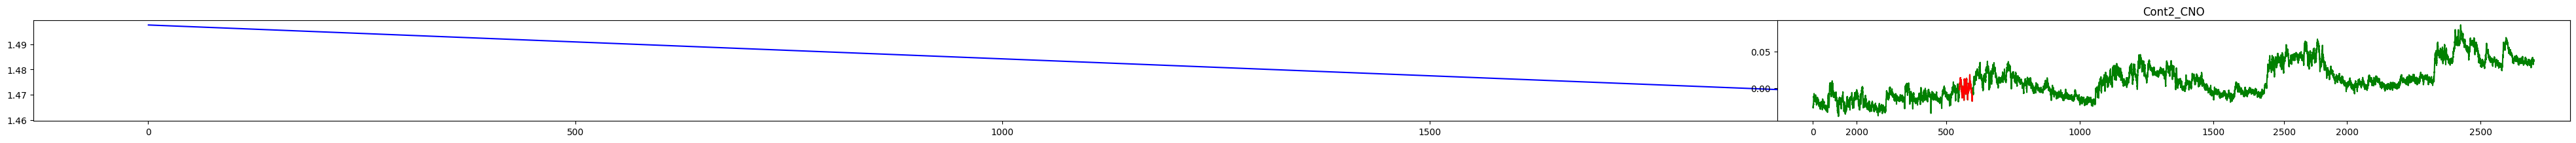

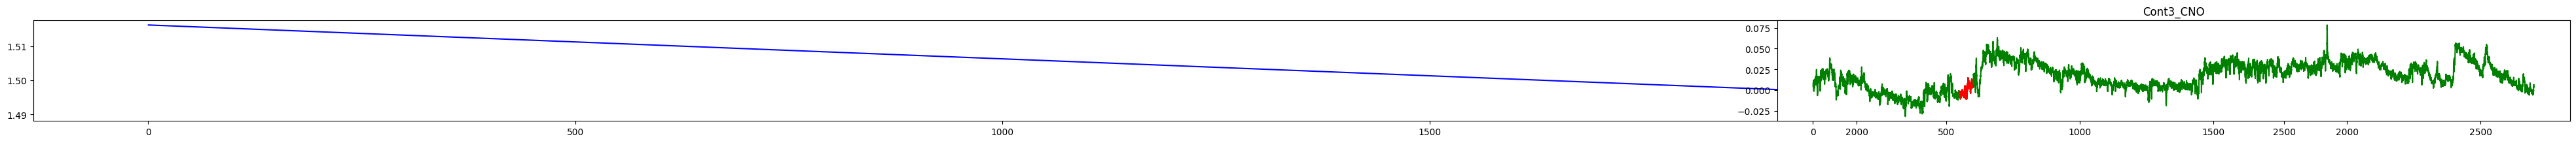

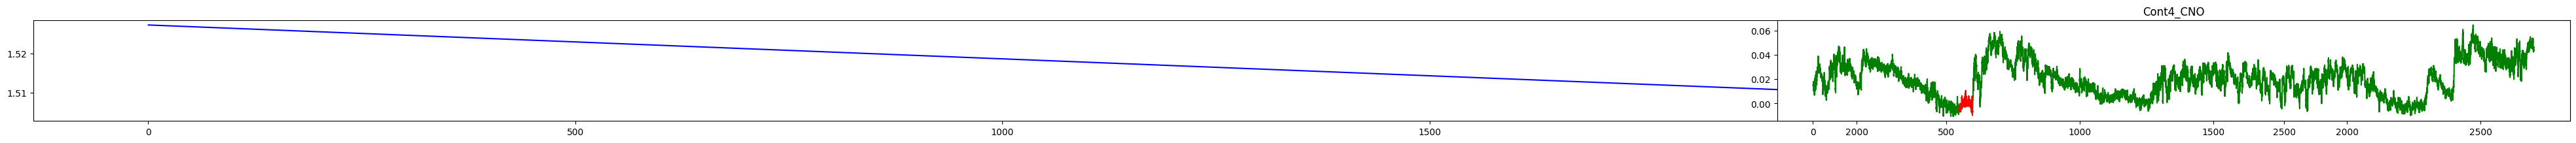

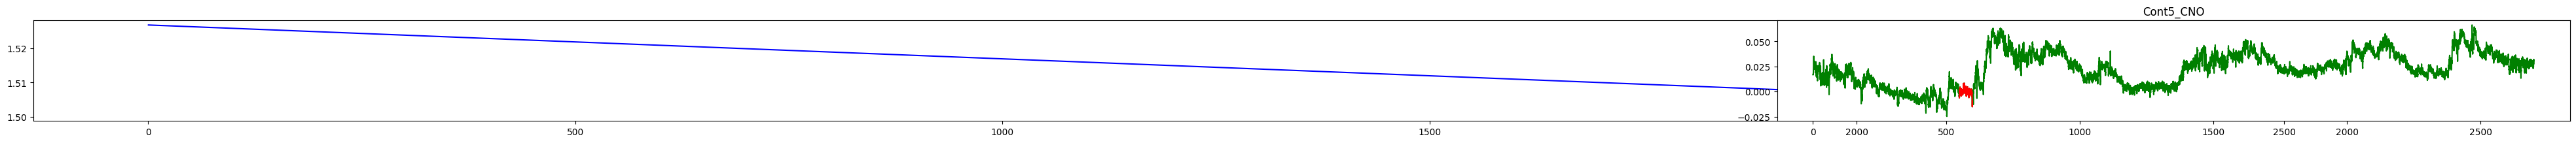

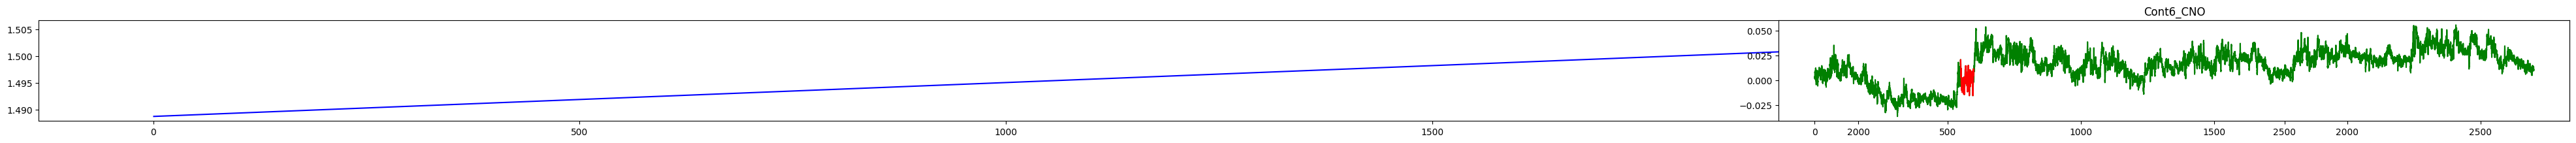

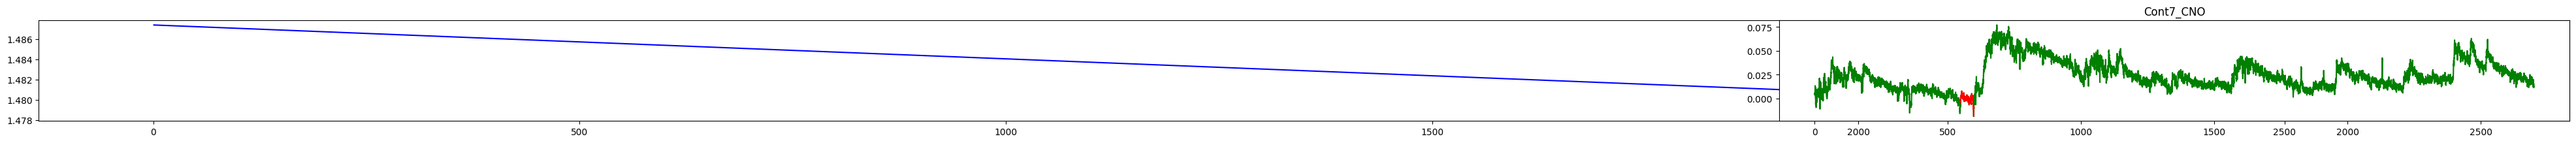

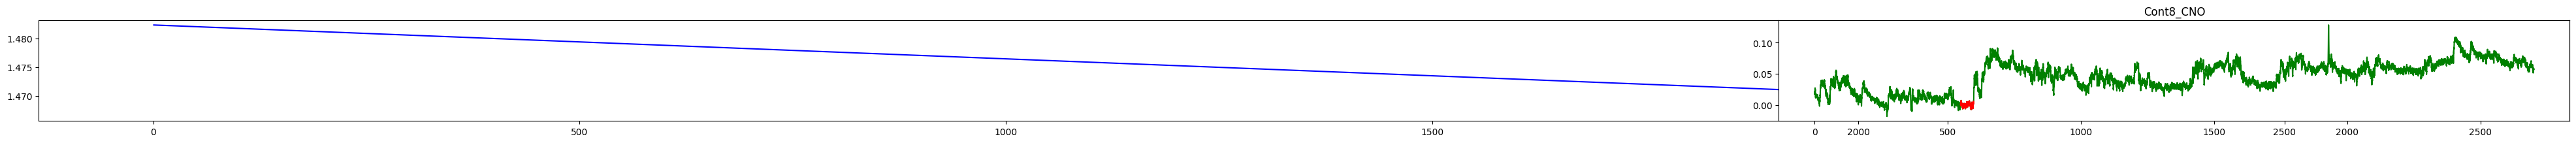

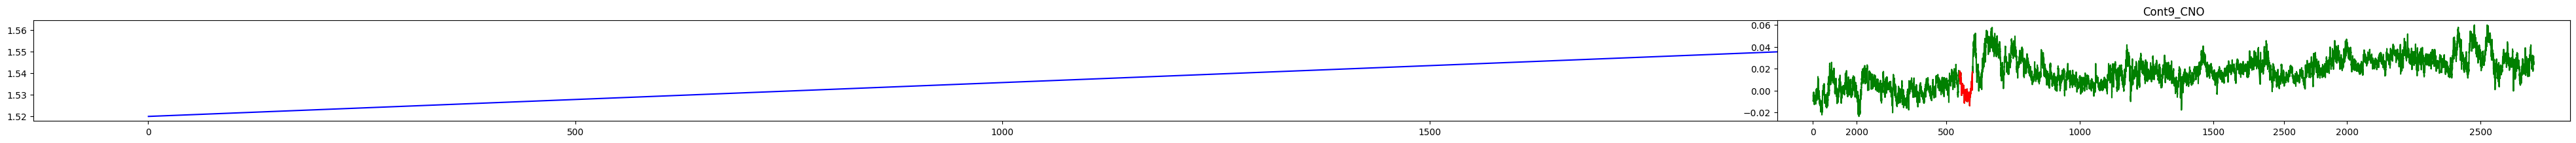

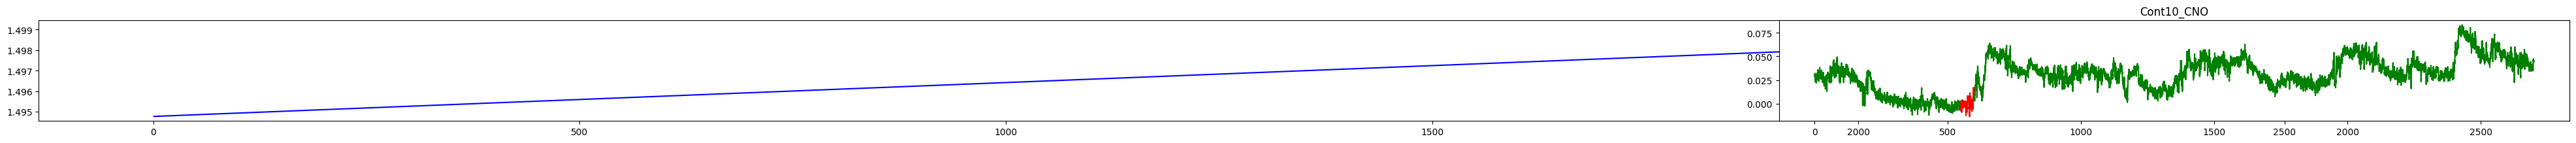

In [ ]:
Cont1_CNO_dFF = dFF_func(time_, Cont1_CNO[:,0], Cont1_CNO[:,1], 0, 2700, 548, 597, 0, "Cont1_CNO")
Cont2_CNO_dFF = dFF_func(time_, Cont2_CNO[:,0], Cont2_CNO[:,1], 0, 2700, 548, 597, 0, "Cont2_CNO")
Cont3_CNO_dFF = dFF_func(time_, Cont3_CNO[:,0], Cont3_CNO[:,1], 0, 2700, 548, 597, 0, "Cont3_CNO")
Cont4_CNO_dFF = dFF_func(time_, Cont4_CNO[:,0], Cont4_CNO[:,1], 0, 2700, 548, 597, 0, "Cont4_CNO")
Cont5_CNO_dFF = dFF_func(time_, Cont5_CNO[:,0], Cont5_CNO[:,1], 0, 2700, 548, 597, 0, "Cont5_CNO")
Cont6_CNO_dFF = dFF_func(time_, Cont6_CNO[:,0], Cont6_CNO[:,1], 0, 2700, 548, 597, 0, "Cont6_CNO")
Cont7_CNO_dFF = dFF_func(time_, Cont7_CNO[:,0], Cont7_CNO[:,1], 0, 2700, 548, 597, 0, "Cont7_CNO")
Cont8_CNO_dFF = dFF_func(time_, Cont8_CNO[:,0], Cont8_CNO[:,1], 0, 2700, 548, 597, 0, "Cont8_CNO")
Cont9_CNO_dFF = dFF_func(time_, Cont9_CNO[:,0], Cont9_CNO[:,1], 0, 2700, 548, 597, 0, "Cont9_CNO")
Cont10_CNO_dFF = dFF_func(time_, Cont10_CNO[:,0], Cont10_CNO[:,1], 0, 2700, 548, 597, 0, "Cont10_CNO")

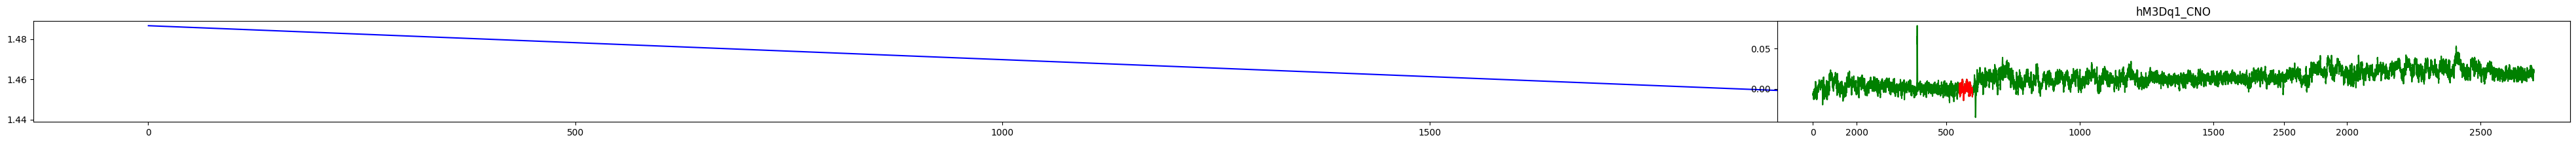

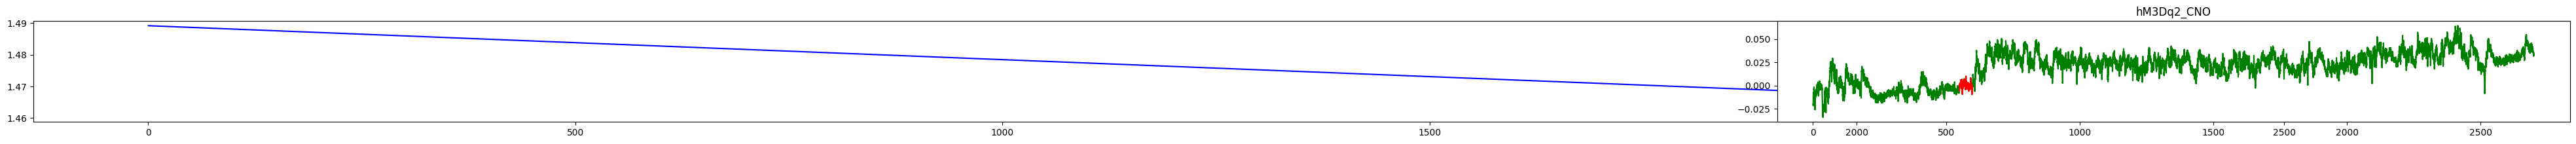

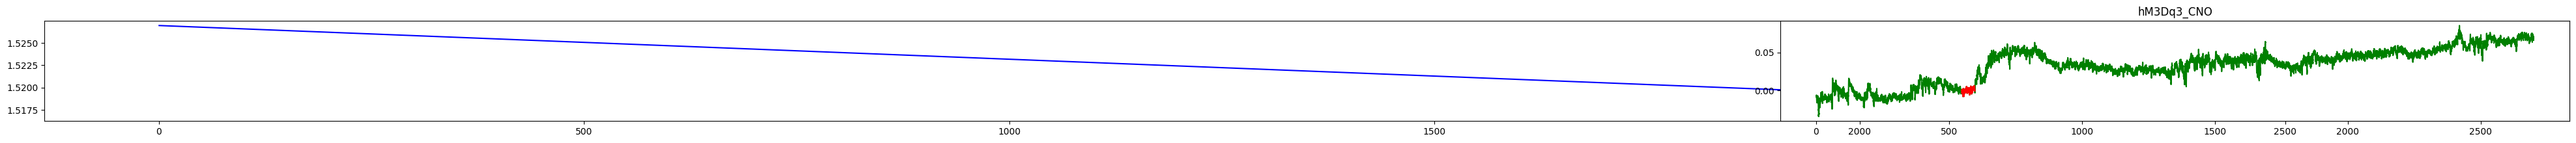

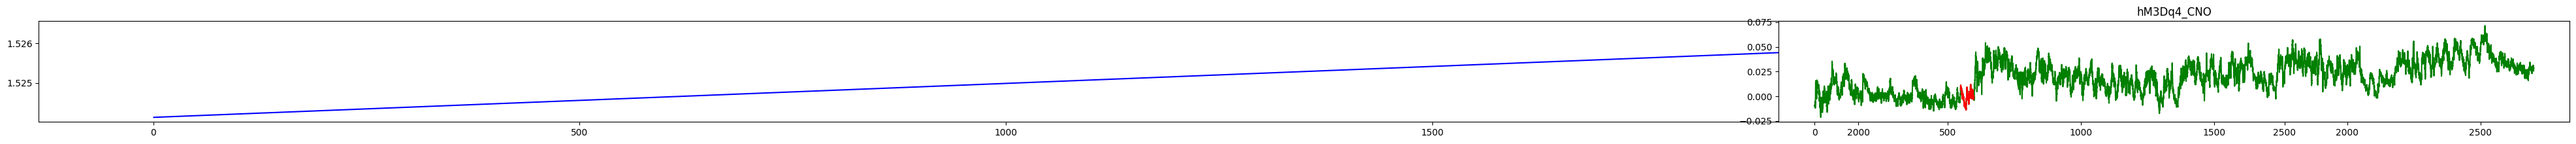

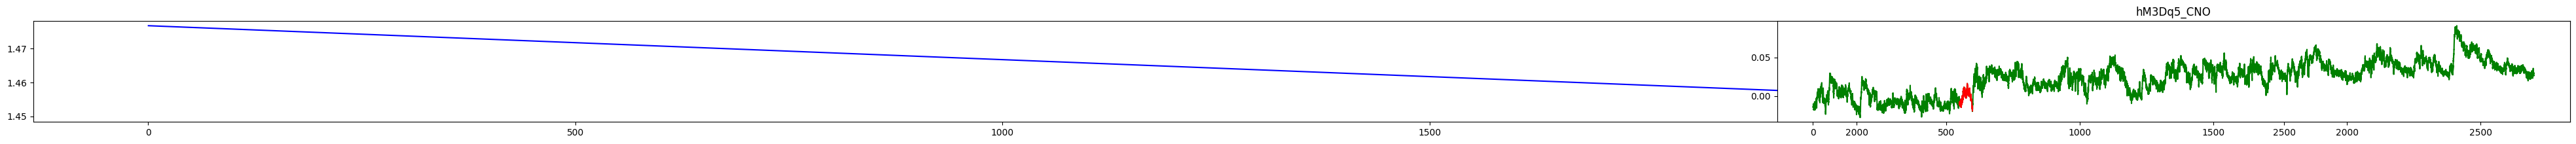

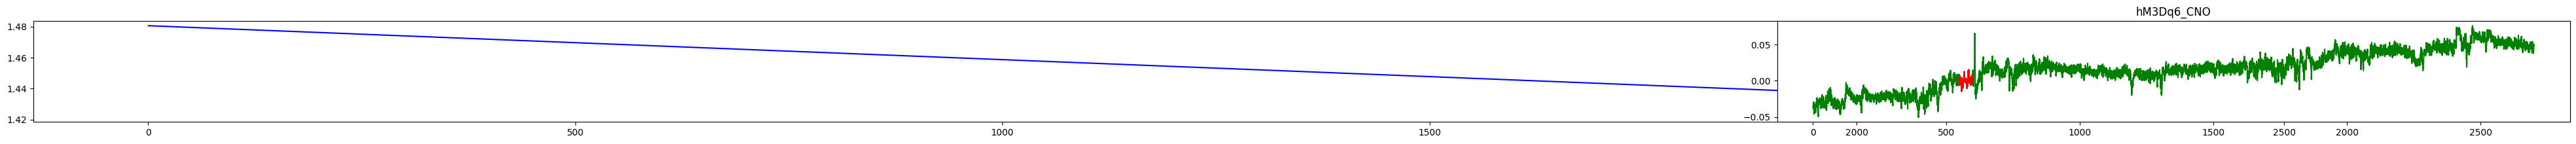

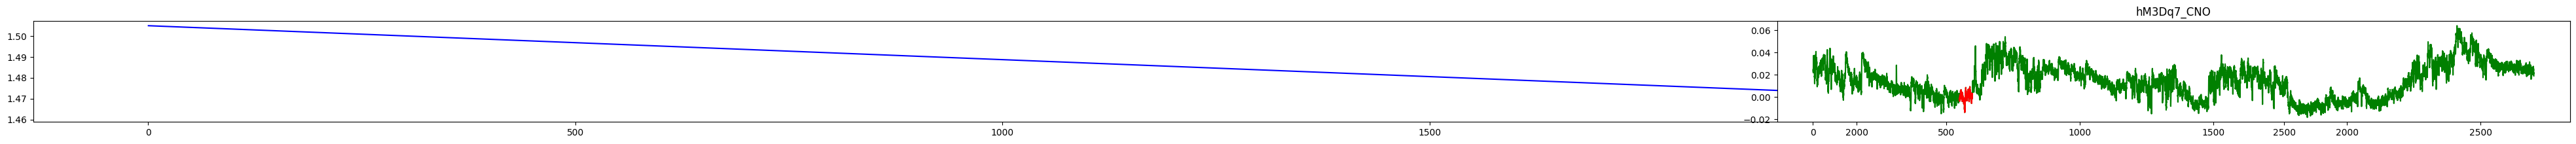

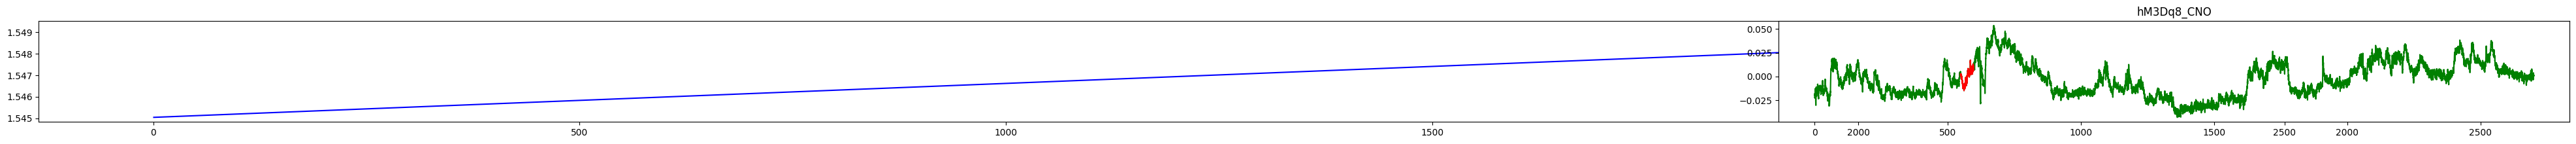

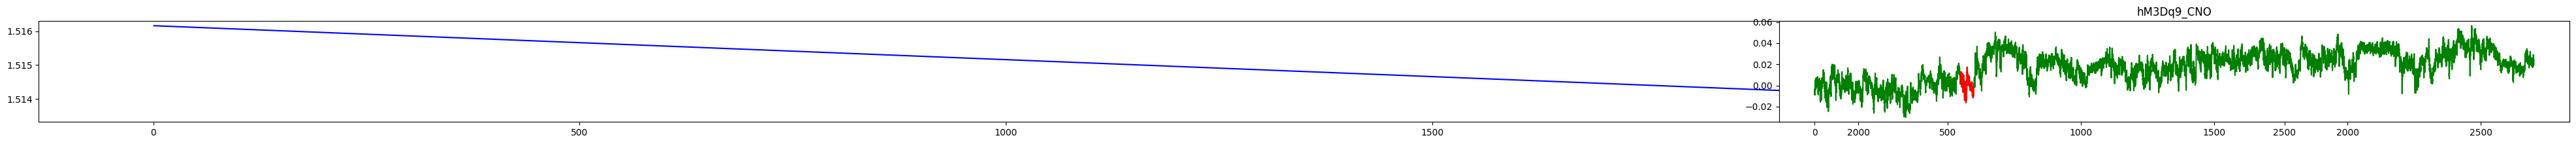

In [ ]:
hM3Dq1_CNO_dFF = dFF_func(time_, hM3Dq1_CNO[:,0], hM3Dq1_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq1_CNO")
hM3Dq2_CNO_dFF = dFF_func(time_, hM3Dq2_CNO[:,0], hM3Dq2_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq2_CNO")
hM3Dq3_CNO_dFF = dFF_func(time_, hM3Dq3_CNO[:,0], hM3Dq3_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq3_CNO")
hM3Dq4_CNO_dFF = dFF_func(time_, hM3Dq4_CNO[:,0], hM3Dq4_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq4_CNO")
hM3Dq5_CNO_dFF = dFF_func(time_, hM3Dq5_CNO[:,0], hM3Dq5_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq5_CNO")
hM3Dq6_CNO_dFF = dFF_func(time_, hM3Dq6_CNO[:,0], hM3Dq6_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq6_CNO")
hM3Dq7_CNO_dFF = dFF_func(time_, hM3Dq7_CNO[:,0], hM3Dq7_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq7_CNO")
hM3Dq8_CNO_dFF = dFF_func(time_, hM3Dq8_CNO[:,0], hM3Dq8_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq8_CNO")
hM3Dq9_CNO_dFF = dFF_func(time_, hM3Dq9_CNO[:,0], hM3Dq9_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq9_CNO")

In [ ]:
Cont_CNO_dFF = pd.DataFrame([Cont1_CNO_dFF, Cont2_CNO_dFF, Cont3_CNO_dFF, Cont4_CNO_dFF, Cont5_CNO_dFF, Cont6_CNO_dFF, Cont7_CNO_dFF, Cont8_CNO_dFF, Cont9_CNO_dFF, Cont10_CNO_dFF]).T

Cont_CNO_dFF.columns = ["Cont1_CNO", "Cont2_CNO", "Cont3_CNO", "Cont4_CNO", "Cont5_CNO", "Cont6_CNO", "Cont7_CNO", "Cont8_CNO", "Cont9_CNO", "Cont10_CNO"]
Cont_CNO_dFF.index = time_

In [ ]:
hM3Dq_CNO_dFF = pd.DataFrame([hM3Dq1_CNO_dFF, hM3Dq2_CNO_dFF, hM3Dq3_CNO_dFF, hM3Dq4_CNO_dFF, hM3Dq5_CNO_dFF, hM3Dq6_CNO_dFF, hM3Dq7_CNO_dFF, hM3Dq8_CNO_dFF, hM3Dq9_CNO_dFF]).T

hM3Dq_CNO_dFF.columns = ["hM3Dq1_CNO", "hM3Dq2_CNO", "hM3Dq3_CNO", "hM3Dq4_CNO", "hM3Dq5_CNO", "hM3Dq6_CNO", "hM3Dq7_CNO", "hM3Dq8_CNO", "hM3Dq9_CNO"]
hM3Dq_CNO_dFF.index = time_

# hM3Dq analysis peak

In [ ]:
puff1_start_post, puff1_end_post = idx_of_the_nearest(time_, 2388), idx_of_the_nearest(time_, 2457)+1
puff2_start_post, puff2_end_post = idx_of_the_nearest(time_, 2458), idx_of_the_nearest(time_, 2517)+1
puff3_start_post, puff3_end_post = idx_of_the_nearest(time_, 2518), idx_of_the_nearest(time_, 2577)+1

### NonD Control CNO

In [ ]:
Cont_CNO_puff1_peakInd_pre = Cont_CNO_dFF.iloc[puff1_start_post:puff1_end_post,:].idxmax()
Cont_CNO_puff2_peakInd_pre = Cont_CNO_dFF.iloc[puff2_start_post:puff2_end_post,:].idxmax()
Cont_CNO_puff3_peakInd_pre = Cont_CNO_dFF.iloc[puff3_start_post:puff3_end_post,:].idxmax()

/tmp/ipykernel_5633/690418065.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax1.scatter(Cont_CNO_puff1_peakInd_pre[i], Cont_CNO_dFF.loc[Cont_CNO_puff1_peakInd_pre[i],c], color="black")
/tmp/ipykernel_5633/690418065.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.scatter(Cont_CNO_puff2_peakInd_pre[i], Cont_CNO_dFF.loc[Cont_CNO_puff2_peakInd_pre[i],c], color="black")
/tmp/ipykernel_5633/690418065.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by p

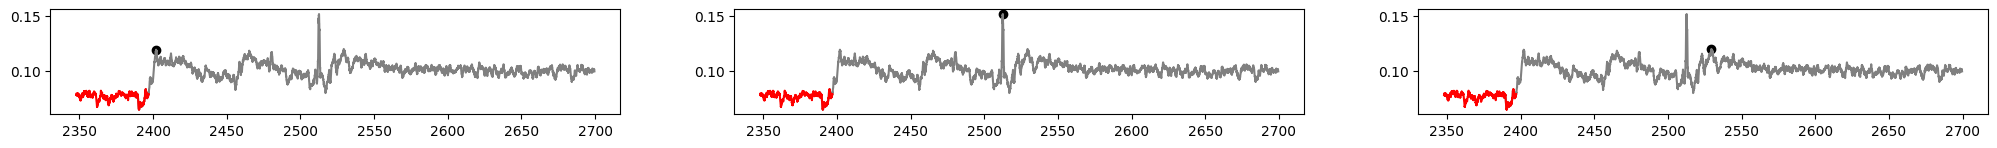

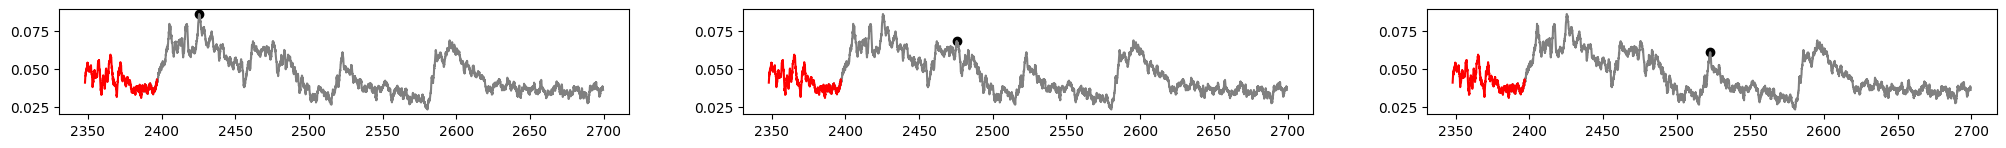

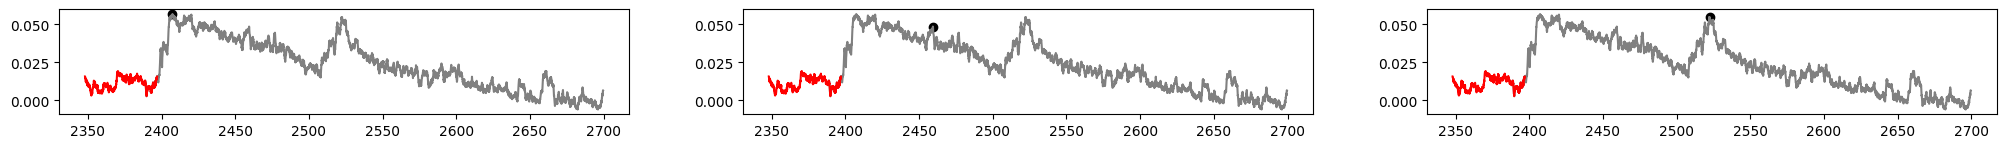

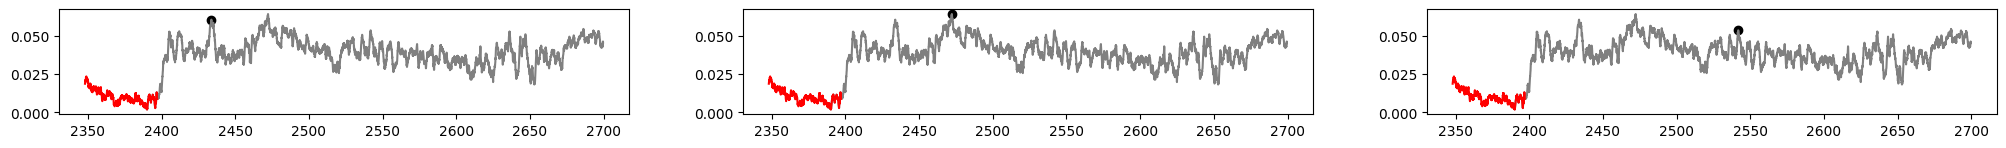

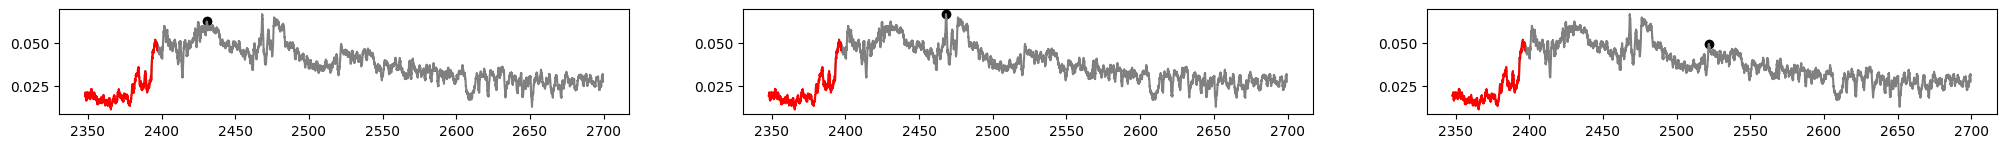

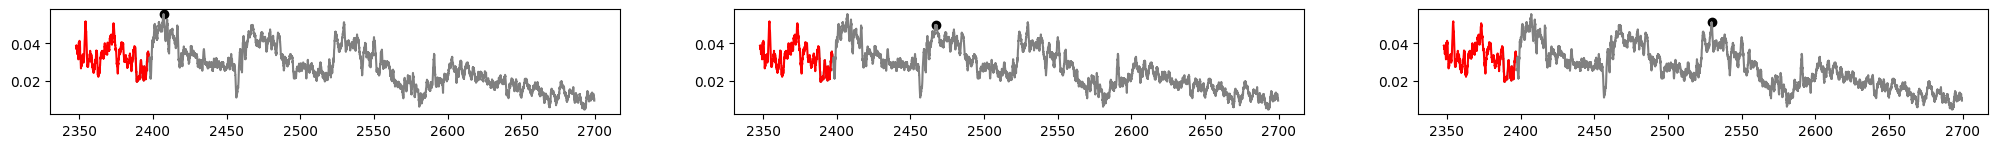

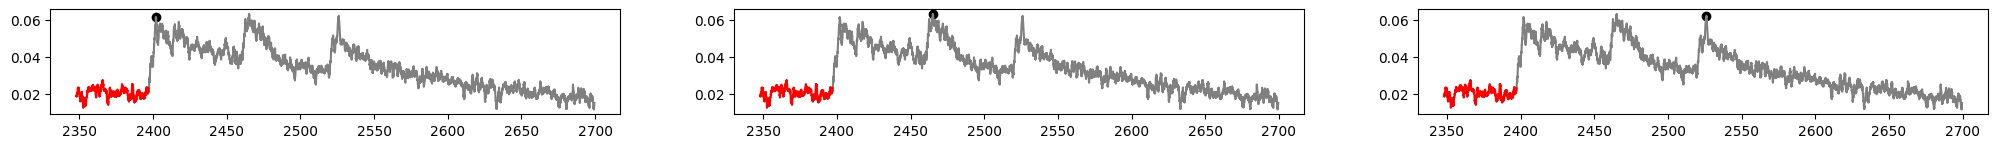

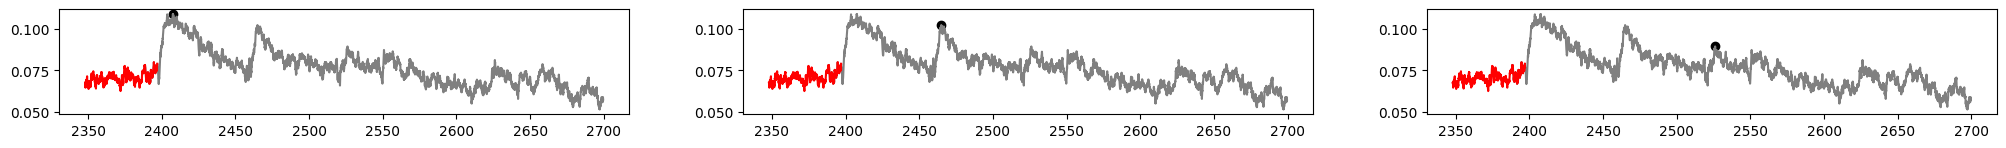

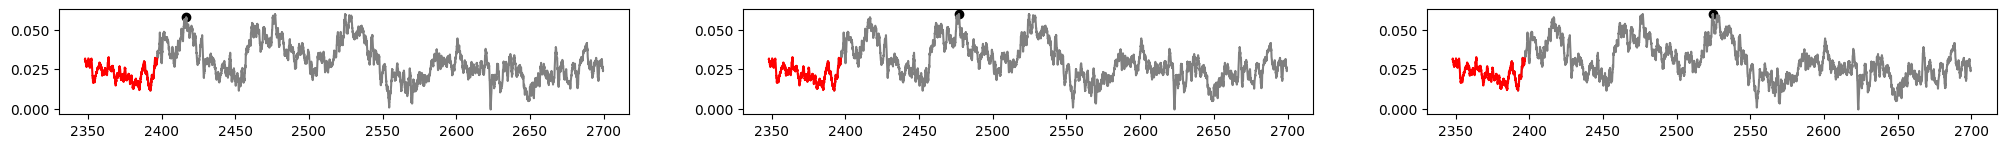

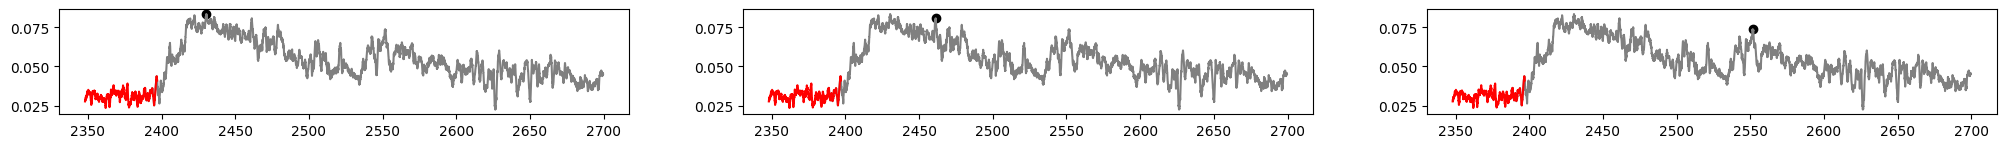

In [ ]:
for i,c in enumerate(Cont_CNO_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)


    ax1.plot(Cont_CNO_dFF.iloc[puff1_start_post:,i].index, Cont_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax1.plot(Cont_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], Cont_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax1.scatter(Cont_CNO_puff1_peakInd_pre[i], Cont_CNO_dFF.loc[Cont_CNO_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(Cont_CNO_dFF.iloc[puff1_start_post:,i].index, Cont_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax2.plot(Cont_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], Cont_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax2.scatter(Cont_CNO_puff2_peakInd_pre[i], Cont_CNO_dFF.loc[Cont_CNO_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax3.plot(Cont_CNO_dFF.iloc[puff1_start_post:,i].index, Cont_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax3.plot(Cont_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], Cont_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax3.scatter(Cont_CNO_puff3_peakInd_pre[i], Cont_CNO_dFF.loc[Cont_CNO_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

In [ ]:
def peak_func(dFF_data, peakInd):
    peak_dict = {}

    for i, mouse in enumerate(dFF_data.columns):
        peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]

    return peak_dict

In [ ]:
peak_func(Cont_CNO_dFF, Cont_CNO_puff1_peakInd_pre)

/tmp/ipykernel_5633/1951324352.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'Cont1_CNO': np.float64(0.11898523574489706),
 'Cont2_CNO': np.float64(0.08581963044534824),
 'Cont3_CNO': np.float64(0.056820771735534015),
 'Cont4_CNO': np.float64(0.06077329601074932),
 'Cont5_CNO': np.float64(0.06204591016604233),
 'Cont6_CNO': np.float64(0.055606856460539866),
 'Cont7_CNO': np.float64(0.06126226802837753),
 'Cont8_CNO': np.float64(0.10876809025698808),
 'Cont9_CNO': np.float64(0.05776398718289544),
 'Cont10_CNO': np.float64(0.08344877980198595)}

In [ ]:
peak_func(Cont_CNO_dFF, Cont_CNO_puff2_peakInd_pre)

/tmp/ipykernel_5633/1951324352.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'Cont1_CNO': np.float64(0.1515352541653967),
 'Cont2_CNO': np.float64(0.06818424451712746),
 'Cont3_CNO': np.float64(0.04857624350539158),
 'Cont4_CNO': np.float64(0.06445582104381165),
 'Cont5_CNO': np.float64(0.06626528262938092),
 'Cont6_CNO': np.float64(0.049862015494373635),
 'Cont7_CNO': np.float64(0.0629775200447763),
 'Cont8_CNO': np.float64(0.10216140474116053),
 'Cont9_CNO': np.float64(0.05987047506879839),
 'Cont10_CNO': np.float64(0.0807518688990797)}

In [ ]:
peak_func(Cont_CNO_dFF, Cont_CNO_puff3_peakInd_pre)

/tmp/ipykernel_5633/1951324352.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'Cont1_CNO': np.float64(0.1196573969410073),
 'Cont2_CNO': np.float64(0.060874773148577255),
 'Cont3_CNO': np.float64(0.054796437315983715),
 'Cont4_CNO': np.float64(0.05375641348811955),
 'Cont5_CNO': np.float64(0.04920870130227273),
 'Cont6_CNO': np.float64(0.051200147875173574),
 'Cont7_CNO': np.float64(0.061988472092811775),
 'Cont8_CNO': np.float64(0.08936169047895137),
 'Cont9_CNO': np.float64(0.05980764586622356),
 'Cont10_CNO': np.float64(0.07362202203279844)}

In [ ]:
Cont_CNO_dFF.to_excel('Cont_CNO_dFFF.xlsx')

### hM3Dq 1.0 CNO

In [ ]:
hM3Dq_CNO_puff1_peakInd_pre = hM3Dq_CNO_dFF.iloc[puff1_start_post:puff1_end_post,:].idxmax()
hM3Dq_CNO_puff2_peakInd_pre = hM3Dq_CNO_dFF.iloc[puff2_start_post:puff2_end_post,:].idxmax()
hM3Dq_CNO_puff3_peakInd_pre = hM3Dq_CNO_dFF.iloc[puff3_start_post:puff3_end_post,:].idxmax()

/tmp/ipykernel_5633/2440886021.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax1.scatter(hM3Dq_CNO_puff1_peakInd_pre[i], hM3Dq_CNO_dFF.loc[hM3Dq_CNO_puff1_peakInd_pre[i],c], color="black")
/tmp/ipykernel_5633/2440886021.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.scatter(hM3Dq_CNO_puff2_peakInd_pre[i], hM3Dq_CNO_dFF.loc[hM3Dq_CNO_puff2_peakInd_pre[i],c], color="black")
/tmp/ipykernel_5633/2440886021.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a v

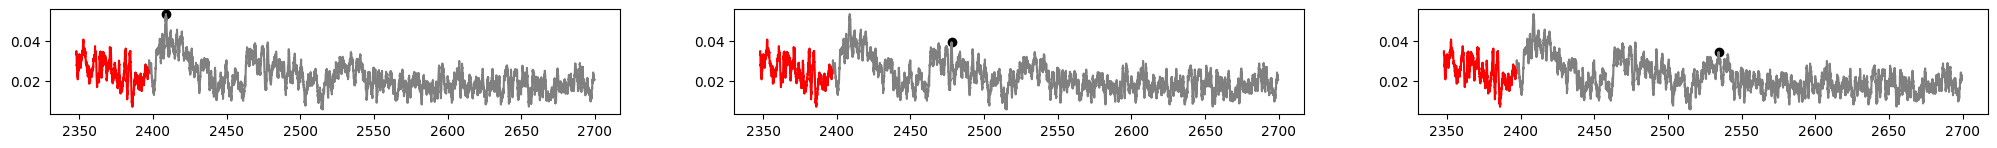

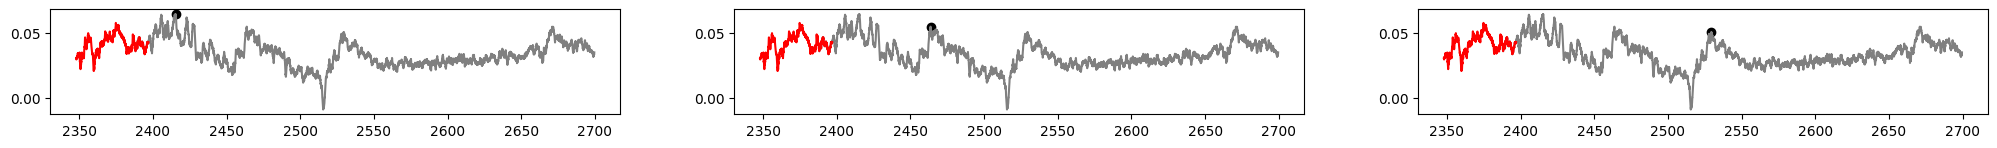

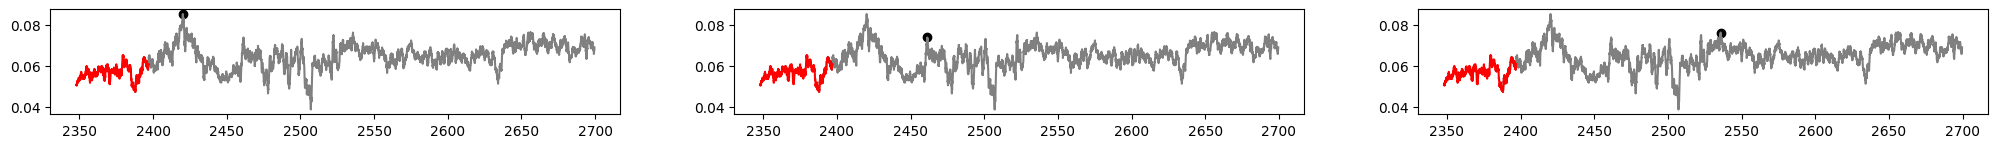

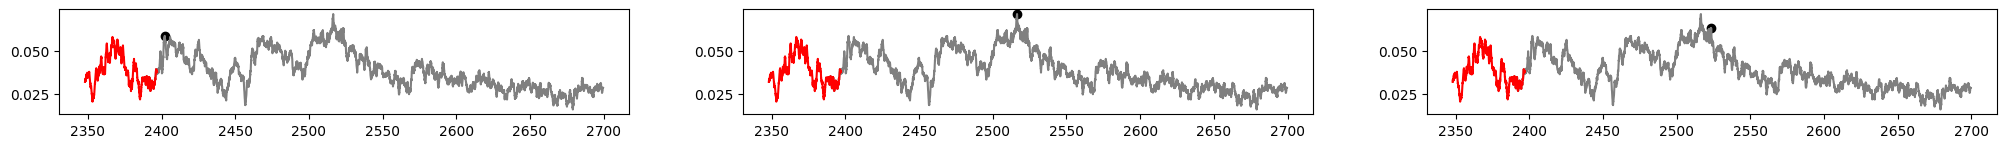

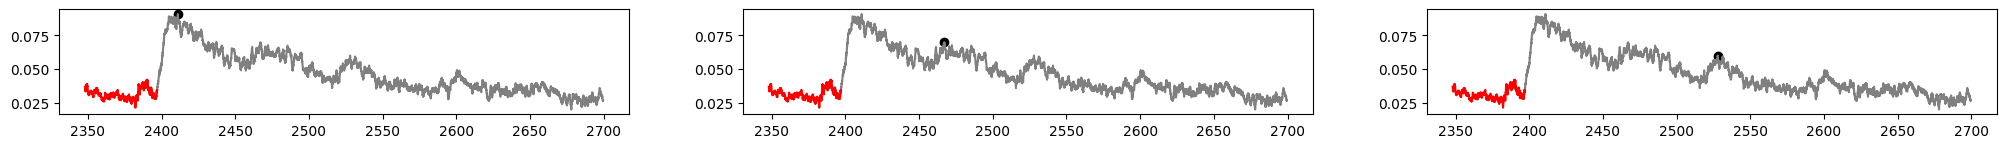

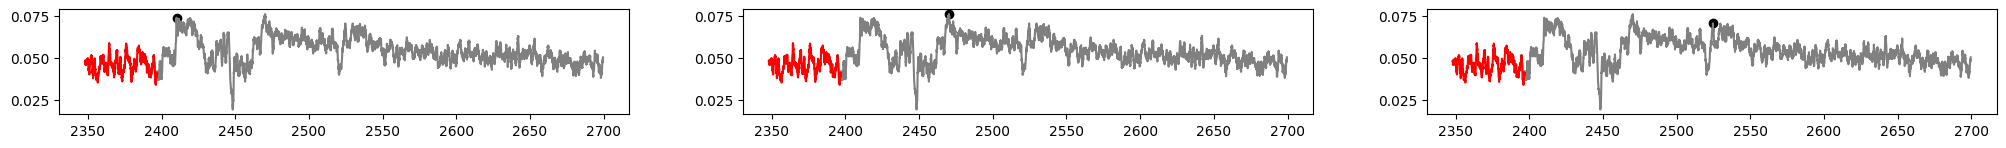

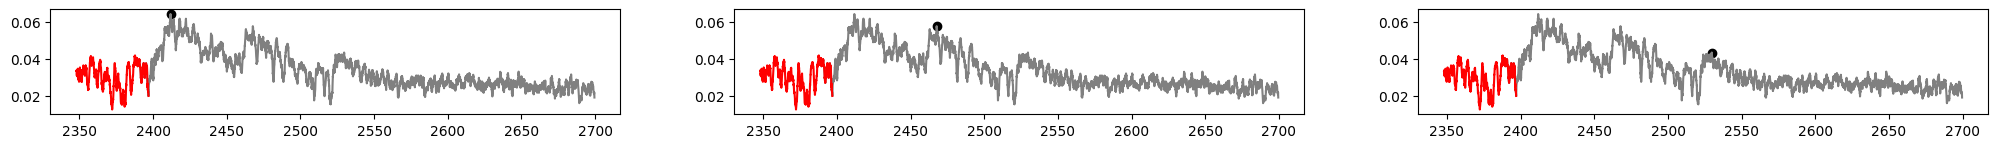

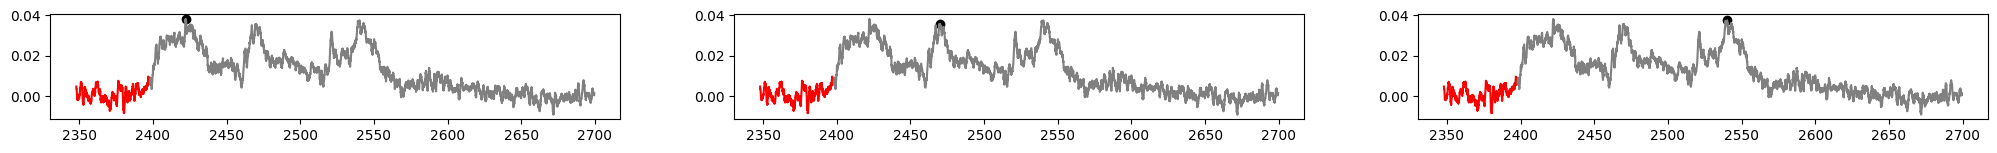

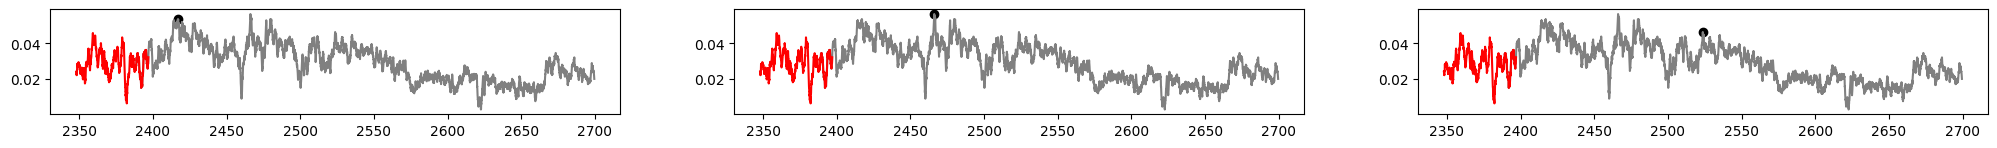

In [ ]:
for i,c in enumerate(hM3Dq_CNO_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)


    ax1.plot(hM3Dq_CNO_dFF.iloc[puff1_start_post:,i].index, hM3Dq_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax1.plot(hM3Dq_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax1.scatter(hM3Dq_CNO_puff1_peakInd_pre[i], hM3Dq_CNO_dFF.loc[hM3Dq_CNO_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(hM3Dq_CNO_dFF.iloc[puff1_start_post:,i].index, hM3Dq_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax2.plot(hM3Dq_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax2.scatter(hM3Dq_CNO_puff2_peakInd_pre[i], hM3Dq_CNO_dFF.loc[hM3Dq_CNO_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax3.plot(hM3Dq_CNO_dFF.iloc[puff1_start_post:,i].index, hM3Dq_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax3.plot(hM3Dq_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax3.scatter(hM3Dq_CNO_puff3_peakInd_pre[i], hM3Dq_CNO_dFF.loc[hM3Dq_CNO_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

In [ ]:
peak_func(hM3Dq_CNO_dFF, hM3Dq_CNO_puff1_peakInd_pre)

/tmp/ipykernel_5633/1951324352.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'hM3Dq1_CNO': np.float64(0.053095407967663544),
 'hM3Dq2_CNO': np.float64(0.06451476135264289),
 'hM3Dq3_CNO': np.float64(0.08548726685682784),
 'hM3Dq4_CNO': np.float64(0.05871657304535183),
 'hM3Dq5_CNO': np.float64(0.09090801779841895),
 'hM3Dq6_CNO': np.float64(0.07404291944966235),
 'hM3Dq7_CNO': np.float64(0.06408387226919532),
 'hM3Dq8_CNO': np.float64(0.038208161156886966),
 'hM3Dq9_CNO': np.float64(0.05356434925686493)}

In [ ]:
peak_func(hM3Dq_CNO_dFF, hM3Dq_CNO_puff2_peakInd_pre)

/tmp/ipykernel_5633/1951324352.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'hM3Dq1_CNO': np.float64(0.039154417889573745),
 'hM3Dq2_CNO': np.float64(0.05482095273603593),
 'hM3Dq3_CNO': np.float64(0.07399122317726459),
 'hM3Dq4_CNO': np.float64(0.07141997351153928),
 'hM3Dq5_CNO': np.float64(0.06991228182975195),
 'hM3Dq6_CNO': np.float64(0.07626171010321281),
 'hM3Dq7_CNO': np.float64(0.05752197424370509),
 'hM3Dq8_CNO': np.float64(0.03581189439763577),
 'hM3Dq9_CNO': np.float64(0.056493942798606644)}

In [ ]:
peak_func(hM3Dq_CNO_dFF, hM3Dq_CNO_puff3_peakInd_pre)

/tmp/ipykernel_5633/1951324352.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'hM3Dq1_CNO': np.float64(0.03441534233225618),
 'hM3Dq2_CNO': np.float64(0.05049968380654457),
 'hM3Dq3_CNO': np.float64(0.07641542128846068),
 'hM3Dq4_CNO': np.float64(0.0632006886408234),
 'hM3Dq5_CNO': np.float64(0.06000617638890171),
 'hM3Dq6_CNO': np.float64(0.07064554204312024),
 'hM3Dq7_CNO': np.float64(0.0432775452411428),
 'hM3Dq8_CNO': np.float64(0.03758485440672099),
 'hM3Dq9_CNO': np.float64(0.04639295501601581)}

In [ ]:
peak_func(hM3Dq_CNO_dFF, hM3Dq_CNO_puff3_peakInd_pre)

/tmp/ipykernel_5633/1951324352.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'hM3Dq1_CNO': np.float64(0.03441534233225618),
 'hM3Dq2_CNO': np.float64(0.05049968380654457),
 'hM3Dq3_CNO': np.float64(0.07641542128846068),
 'hM3Dq4_CNO': np.float64(0.0632006886408234),
 'hM3Dq5_CNO': np.float64(0.06000617638890171),
 'hM3Dq6_CNO': np.float64(0.07064554204312024),
 'hM3Dq7_CNO': np.float64(0.0432775452411428),
 'hM3Dq8_CNO': np.float64(0.03758485440672099),
 'hM3Dq9_CNO': np.float64(0.04639295501601581)}

In [ ]:
hM3Dq_CNO_dFF.to_excel('hM3Dq_CNO_dFF.xlsx')

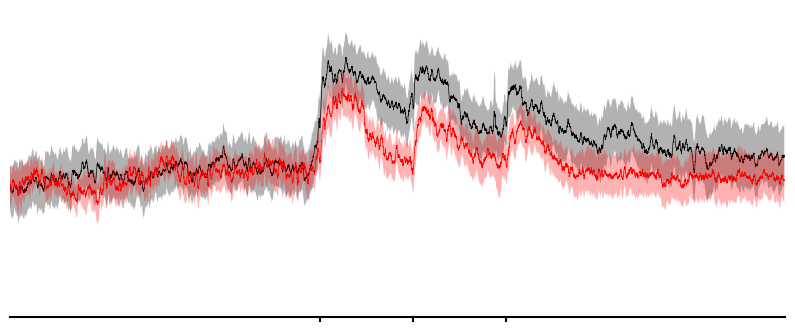

In [ ]:
##figures

Fig_start = idx_of_the_nearest(time_, 0)
Fig_end = idx_of_the_nearest(time_, 2700)

Cont_CNO_mean = Cont_CNO_dFF.mean(axis=1)
hM3Dq_CNO_mean = hM3Dq_CNO_dFF.mean(axis=1)
#Cont_saline_mean = Cont_saline_dFF.mean(axis=1)
#hM3Dq_saline_mean = hM3Dq_saline_dFF.mean(axis=1)

Cont_CNO_SEM = Cont_CNO_dFF.std(axis=1, ddof=1) / np.sqrt(len(Cont_CNO_dFF.columns))
hM3Dq_CNO_SEM = hM3Dq_CNO_dFF.std(axis=1, ddof=1) / np.sqrt(len(hM3Dq_CNO_dFF.columns))
#Cont_saline_SEM = Cont_saline_dFF.std(axis=1, ddof=1) / np.sqrt(len(Cont_saline_dFF.columns))
#hM3Dq_saline_SEM = hM3Dq_saline_dFF.std(axis=1, ddof=1) / np.sqrt(len(hM3Dq_saline_dFF.columns))

plt.figure(figsize=(10,4))
plt.axvline(x=600, color='black', linestyle="--", linewidth=0.7, zorder=1)


plt.fill_between(Cont_CNO_dFF.index[Fig_start:], Cont_CNO_mean.iloc[Fig_start:] - Cont_CNO_SEM.iloc[Fig_start:], \
                Cont_CNO_mean.iloc[Fig_start:] + Cont_CNO_SEM.iloc[Fig_start:], facecolor='black', lw = 0, alpha=0.3, zorder=2)
plt.plot(Cont_CNO_mean.iloc[Fig_start:], lw = 0.5, color="black")

plt.fill_between(hM3Dq_CNO_dFF.index[Fig_start:], hM3Dq_CNO_mean.iloc[Fig_start:] - hM3Dq_CNO_SEM.iloc[Fig_start:], \
                 hM3Dq_CNO_mean.iloc[Fig_start:] + hM3Dq_CNO_SEM.iloc[Fig_start:], facecolor='red', lw = 0, alpha=0.3, zorder=2)
plt.plot(hM3Dq_CNO_mean.iloc[Fig_start:], lw = 0.5, color="red")

#plt.fill_between(Cont_saline_dFF.index[Fig_start:], Cont_saline_mean.iloc[Fig_start:] - Cont_saline_SEM.iloc[Fig_start:], \
#                Cont_saline_mean.iloc[Fig_start:] + Cont_saline_SEM.iloc[Fig_start:], facecolor='gray', lw = 0, alpha=0.3, zorder=2)
#plt.plot(Cont_saline_mean.iloc[Fig_start:], lw = 0.5, color="gray")

#plt.fill_between(hM3Dq_saline_dFF.index[Fig_start:], hM3Dq_saline_mean.iloc[Fig_start:] - hM3Dq_saline_SEM.iloc[Fig_start:], \
#                 hM3Dq_saline_mean.iloc[Fig_start:] + hM3Dq_saline_SEM.iloc[Fig_start:], facecolor='magenta', lw = 0, alpha=0.3, zorder=2)
#plt.plot(hM3Dq_saline_mean.iloc[Fig_start:], lw = 0.5, color="magenta")


plt.ylim(-0.01, 0.08)
plt.xlim(2200, 2700)
plt.xticks([2400, 2460, 2520])


plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines["bottom"].set_linewidth(1.5)
plt.tick_params(length=3.5, width=1.5)
plt.tick_params(labelbottom=False, labelleft=False)
plt.tick_params(left=False, right=False, top=False)

#plt.savefig("cAMP_hab.png", format="png", dpi=300, transparent=True)

plt.show()

# Adra1a analysis peak

In [ ]:
#puff1_start_pre, puff1_end_pre = idx_of_the_nearest(time_, 48), idx_of_the_nearest(time_, 117)+1
#puff2_start_pre, puff2_end_pre = idx_of_the_nearest(time_, 118), idx_of_the_nearest(time_, 177)+1
#puff3_start_pre, puff3_end_pre = idx_of_the_nearest(time_, 178), idx_of_the_nearest(time_, 237)+1

### Adra1a Control no cre

In [ ]:
Cont_saline_puff1_peakInd_pre = Cont_saline_dFF.iloc[puff1_start_pre:puff1_end_pre,:].idxmax()
Cont_saline_puff2_peakInd_pre = Cont_saline_dFF.iloc[puff2_start_pre:puff2_end_pre,:].idxmax()
Cont_saline_puff3_peakInd_pre = Cont_saline_dFF.iloc[puff3_start_pre:puff3_end_pre,:].idxmax()

/tmp/ipython-input-774256218.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax1.scatter(Cont_saline_puff1_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff1_peakInd_pre[i],c], color="black")
/tmp/ipython-input-774256218.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.scatter(Cont_saline_puff2_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff2_peakInd_pre[i],c], color="black")
/tmp/ipython-input-774256218.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To acce

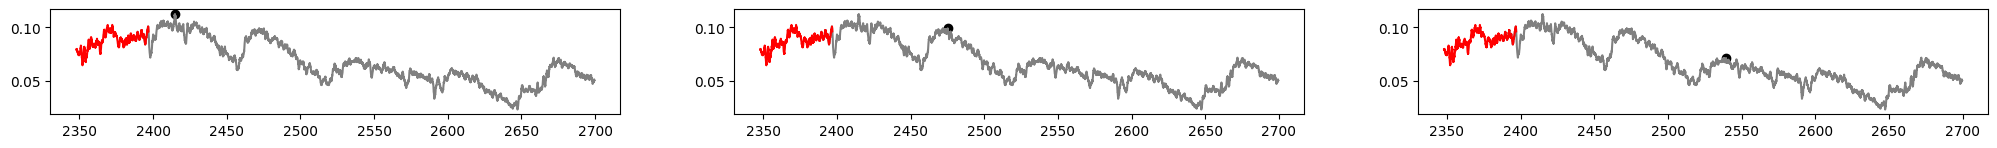

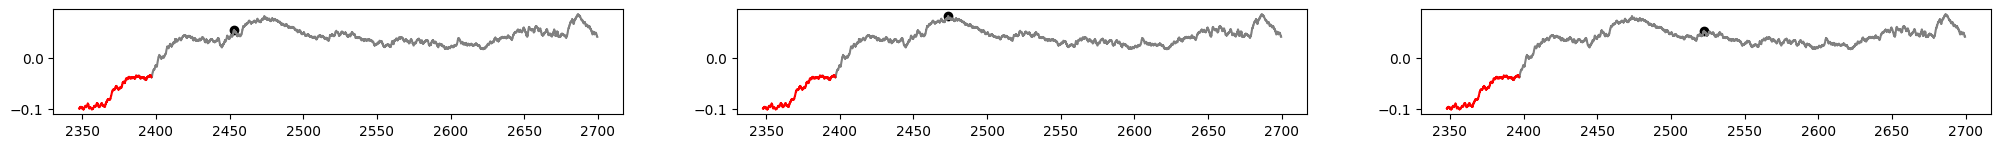

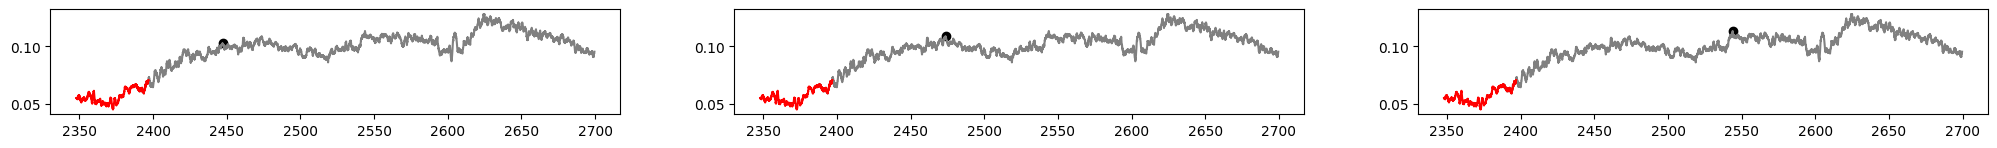

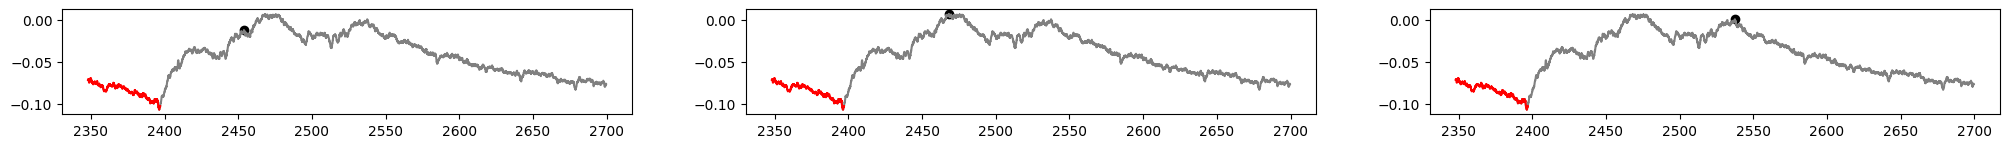

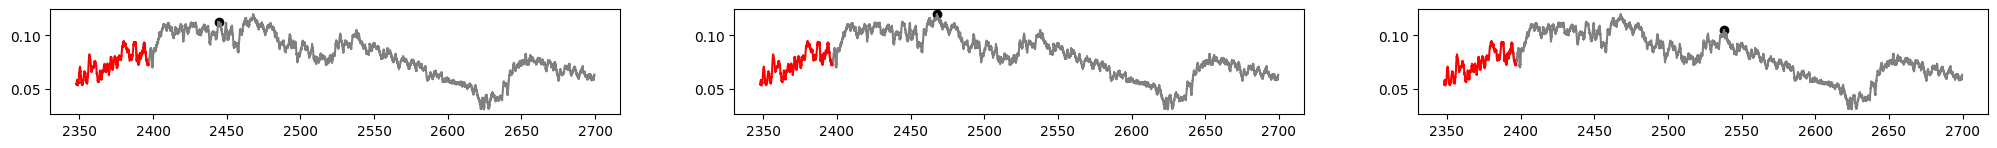

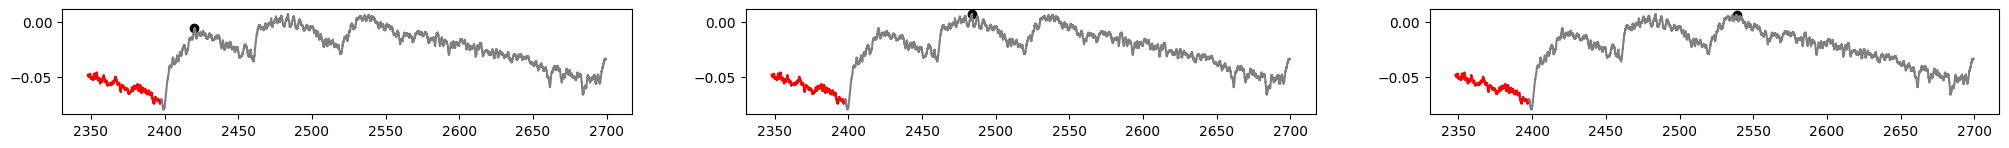

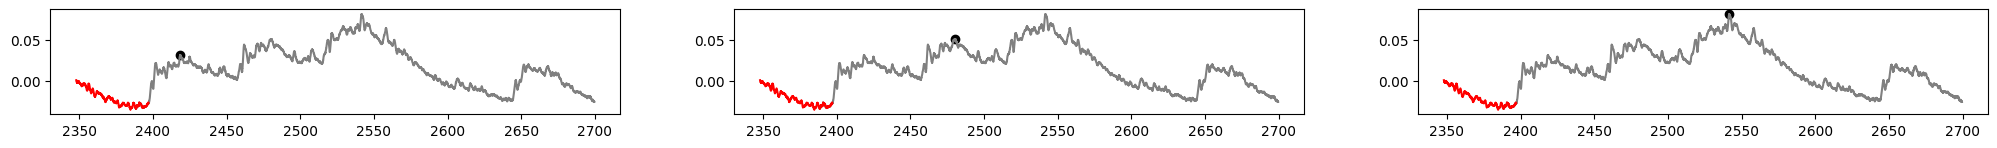

In [ ]:
#postIP data
Cont_saline_puff1_peakInd_pre = Cont_saline_dFF.iloc[puff1_start_post:puff1_end_post,:].idxmax()
Cont_saline_puff2_peakInd_pre = Cont_saline_dFF.iloc[puff2_start_post:puff2_end_post,:].idxmax()
Cont_saline_puff3_peakInd_pre = Cont_saline_dFF.iloc[puff3_start_post:puff3_end_post,:].idxmax()

for i,c in enumerate(Cont_saline_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)


    ax1.plot(Cont_saline_dFF.iloc[puff1_start_post:,i].index, Cont_saline_dFF.iloc[puff1_start_post:,i], color="gray")
    ax1.plot(Cont_saline_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], Cont_saline_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax1.scatter(Cont_saline_puff1_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(Cont_saline_dFF.iloc[puff1_start_post:,i].index, Cont_saline_dFF.iloc[puff1_start_post:,i], color="gray")
    ax2.plot(Cont_saline_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], Cont_saline_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax2.scatter(Cont_saline_puff2_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax3.plot(Cont_saline_dFF.iloc[puff1_start_post:,i].index, Cont_saline_dFF.iloc[puff1_start_post:,i], color="gray")
    ax3.plot(Cont_saline_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], Cont_saline_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax3.scatter(Cont_saline_puff3_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

/tmp/ipython-input-4013554328.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax1.scatter(Cont_saline_puff1_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff1_peakInd_pre[i],c], color="black")
/tmp/ipython-input-4013554328.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.scatter(Cont_saline_puff2_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff2_peakInd_pre[i],c], color="black")
/tmp/ipython-input-4013554328.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To a

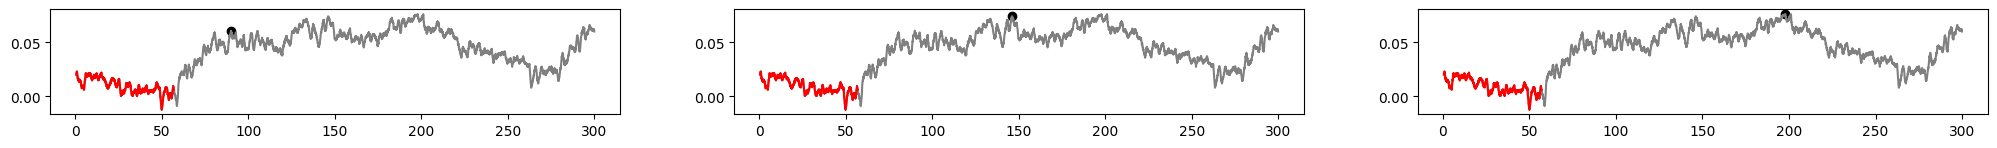

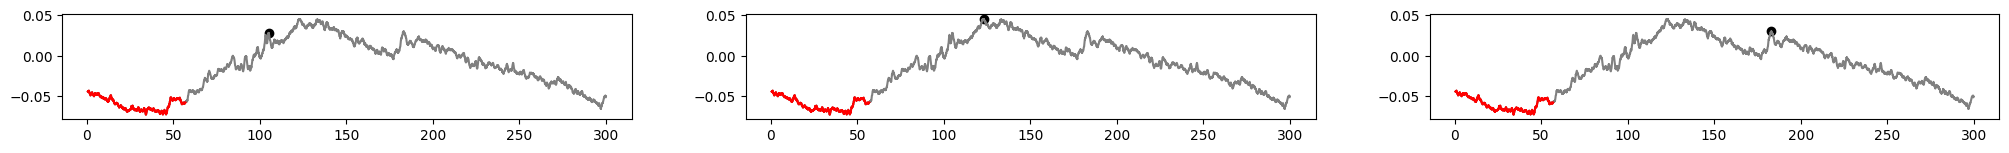

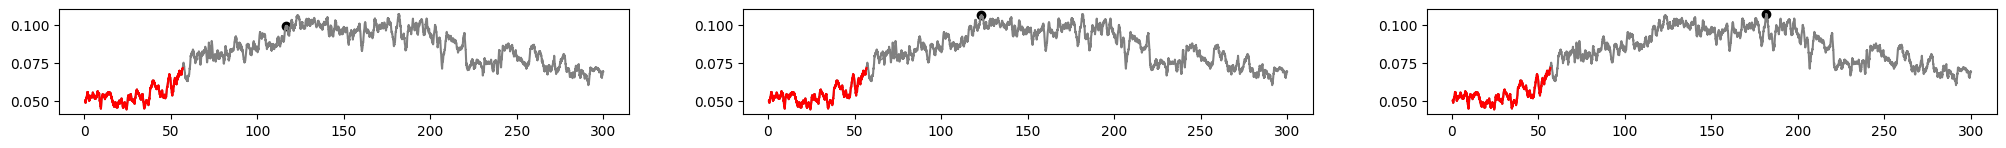

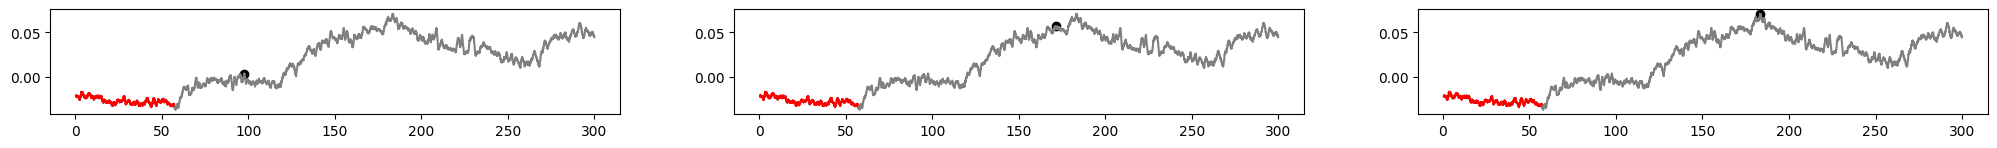

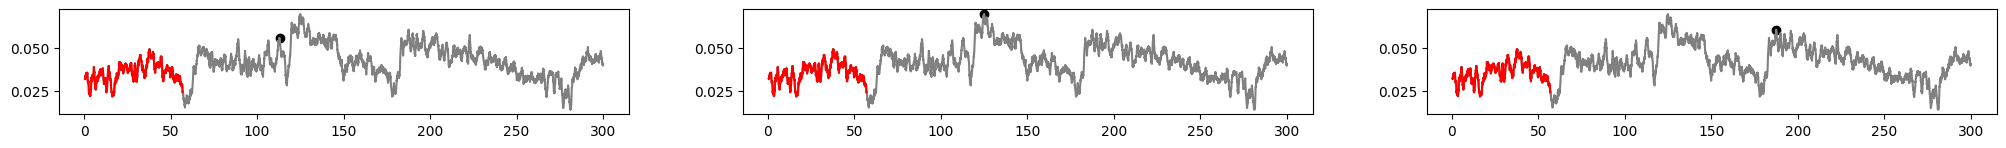

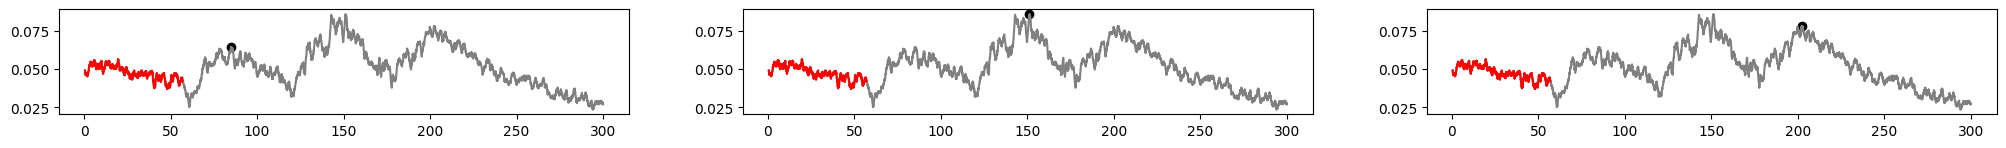

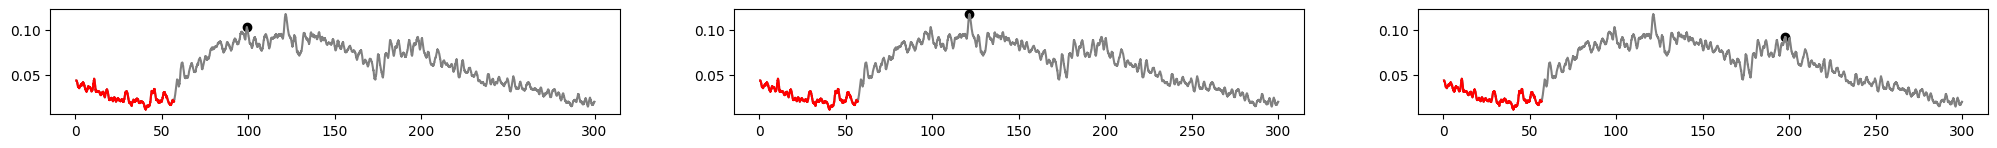

In [ ]:
for i,c in enumerate(Cont_saline_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)


    ax1.plot(Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i].index, Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i], color="gray")
    ax1.plot(Cont_saline_dFF.index[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57)], Cont_saline_dFF.iloc[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57), i], color="red")
    ax1.scatter(Cont_saline_puff1_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i].index, Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i], color="gray")
    ax2.plot(Cont_saline_dFF.index[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57)], Cont_saline_dFF.iloc[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57), i], color="red")
    ax2.scatter(Cont_saline_puff2_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax3.plot(Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i].index, Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i], color="gray")
    ax3.plot(Cont_saline_dFF.index[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57)], Cont_saline_dFF.iloc[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57), i], color="red")
    ax3.scatter(Cont_saline_puff3_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

In [ ]:
peak_func(Cont_saline_dFF, Cont_saline_puff1_peakInd_pre)

NameError: name 'Cont_saline_puff1_peakInd_post' is not defined

In [ ]:
peak_func(Cont_saline_dFF, Cont_saline_puff2_peakInd_pre)

/tmp/ipython-input-2873964455.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'Cont1_saline': np.float64(0.09917106177890311),
 'Cont2_saline': np.float64(0.08061398537286424),
 'Cont3_saline': np.float64(0.10890812660157123),
 'Cont5_saline': np.float64(0.006924623455785817),
 'Cont6_saline': np.float64(0.11990695199593926),
 'Cont7_saline': np.float64(0.007248548932314414),
 'Cont8_saline': np.float64(0.05100371134596948)}

In [ ]:
peak_func(Cont_saline_dFF, Cont_saline_puff3_peakInd_pre)

/tmp/ipython-input-2873964455.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'Cont1_saline': np.float64(0.07146876778661426),
 'Cont2_saline': np.float64(0.0519255906943894),
 'Cont3_saline': np.float64(0.11340111871388281),
 'Cont5_saline': np.float64(0.0007528845663089534),
 'Cont6_saline': np.float64(0.10522363909573751),
 'Cont7_saline': np.float64(0.0066571118550069475),
 'Cont8_saline': np.float64(0.0812982422805325)}

In [ ]:
Cont_saline_dFF.to_excel('/content/drive/MyDrive/Cont_saline_dFF.xlsx')

### Adra1a KO with cre

In [ ]:
KO_saline_puff1_peakInd_pre = KO_saline_dFF.iloc[puff1_start_pre:puff1_end_pre,:].idxmax()
KO_saline_puff2_peakInd_pre = KO_saline_dFF.iloc[puff2_start_pre:puff2_end_pre,:].idxmax()
KO_saline_puff3_peakInd_pre = KO_saline_dFF.iloc[puff3_start_pre:puff3_end_pre,:].idxmax()

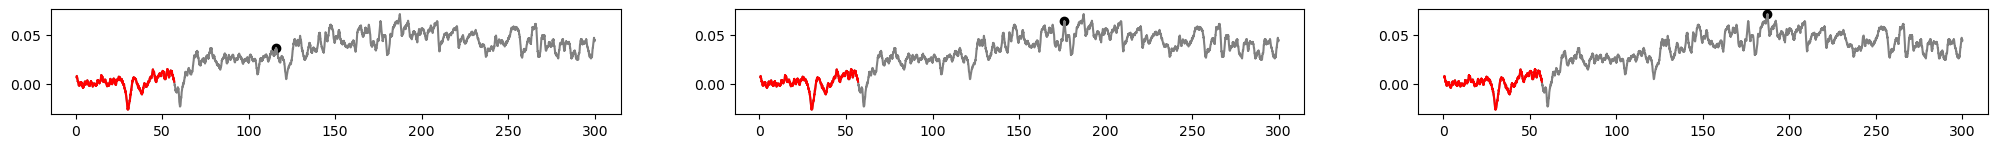

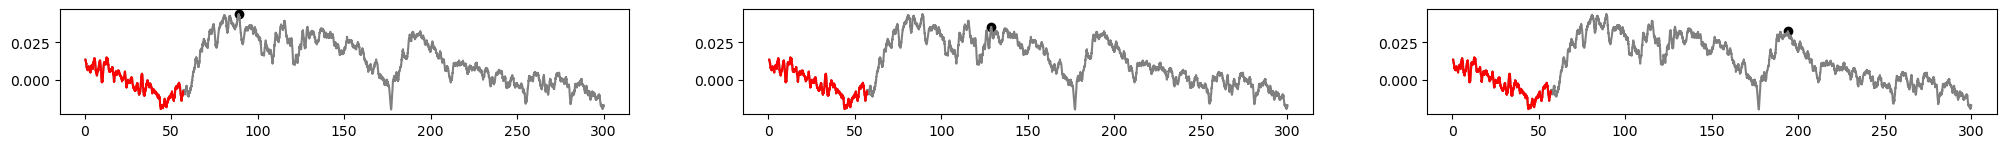

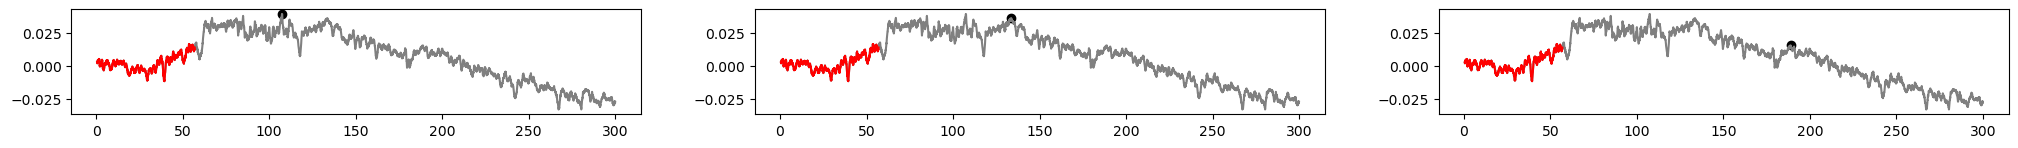

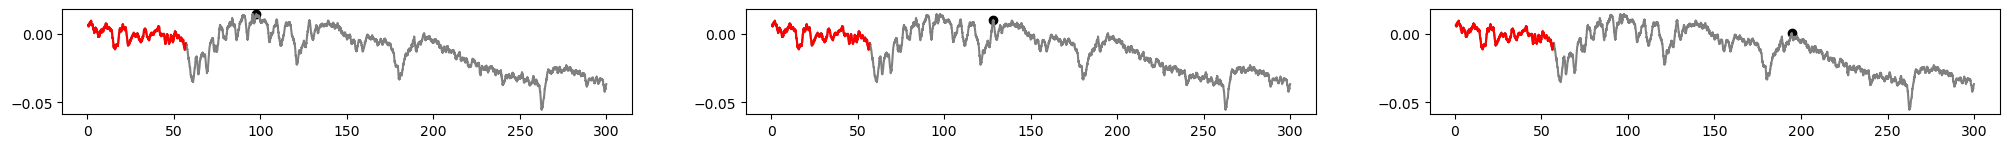

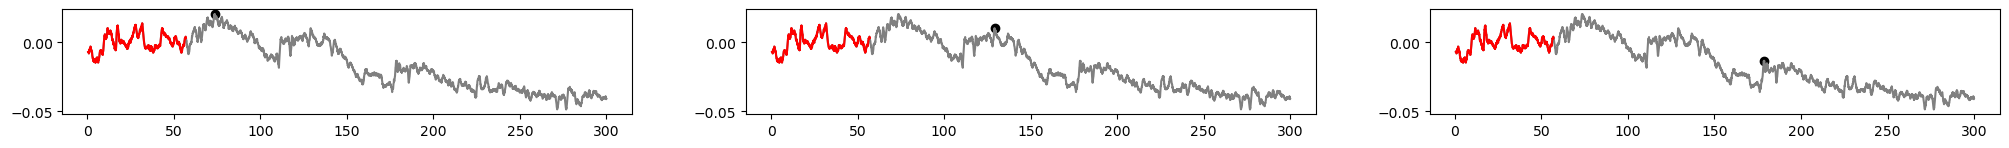

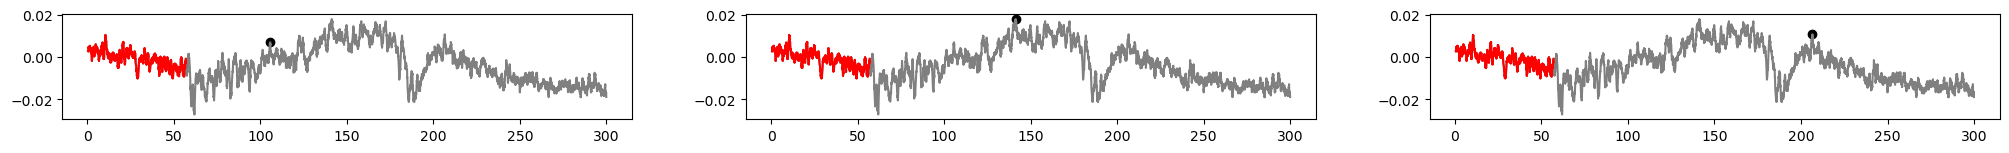

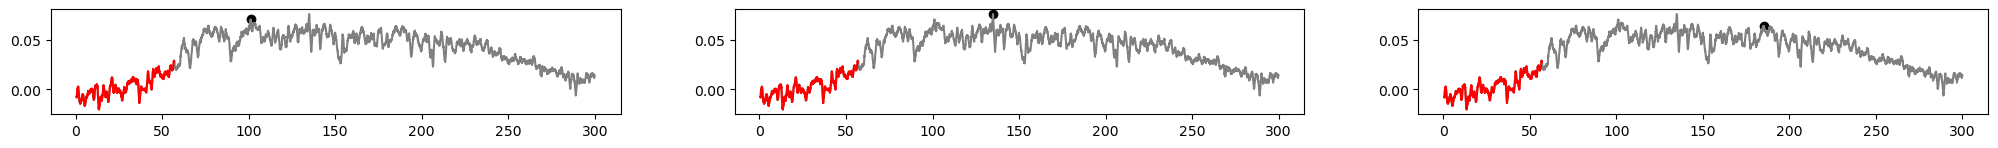

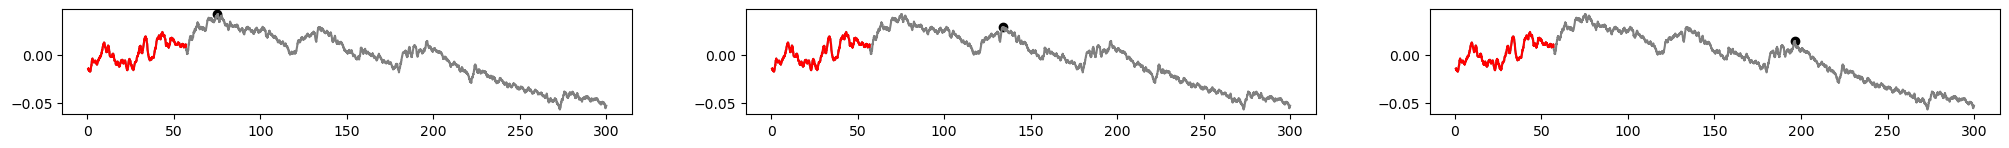

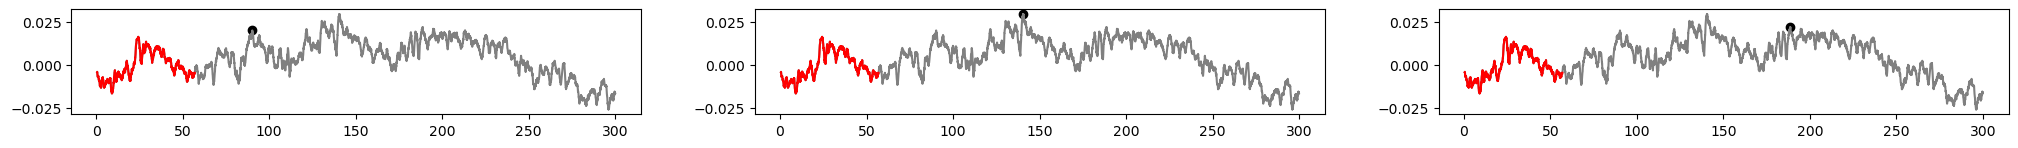

In [ ]:
for i,c in enumerate(KO_saline_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)


    ax1.plot(KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i].index, KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i], color="gray")
    ax1.plot(KO_saline_dFF.index[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57)], KO_saline_dFF.iloc[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57), i], color="red")
    ax1.scatter(KO_saline_puff1_peakInd_pre[i], KO_saline_dFF.loc[KO_saline_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i].index, KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i], color="gray")
    ax2.plot(KO_saline_dFF.index[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57)], KO_saline_dFF.iloc[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57), i], color="red")
    ax2.scatter(KO_saline_puff2_peakInd_pre[i], KO_saline_dFF.loc[KO_saline_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax3.plot(KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i].index, KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i], color="gray")
    ax3.plot(KO_saline_dFF.index[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57)], KO_saline_dFF.iloc[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57), i], color="red")
    ax3.scatter(KO_saline_puff3_peakInd_pre[i], KO_saline_dFF.loc[KO_saline_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

In [ ]:
peak_func(KO_saline_dFF, KO_saline_puff1_peakInd_pre)

{'KO1_saline': 0.03687237235938601,
 'KO2_saline': 0.043950912017028276,
 'KO3_saline': 0.039148615245807594,
 'KO4_saline': 0.014351915792550907,
 'KO5_saline': 0.020656003438471737,
 'KO6_saline': 0.00693891477771813,
 'KO7_saline': 0.07093692376359662,
 'KO8_saline': 0.04198443655747375,
 'KO9_saline': 0.02006855218687531}

In [ ]:
peak_func(KO_saline_dFF, KO_saline_puff2_peakInd_pre)

{'KO1_saline': 0.06427731953288407,
 'KO2_saline': 0.03546861652138289,
 'KO3_saline': 0.03588835161915371,
 'KO4_saline': 0.009762593592198554,
 'KO5_saline': 0.01039900450032416,
 'KO6_saline': 0.01794513954285204,
 'KO7_saline': 0.07639987331786657,
 'KO8_saline': 0.028529583366408096,
 'KO9_saline': 0.029602596516922874}

In [ ]:
peak_func(KO_saline_dFF, KO_saline_puff3_peakInd_pre)

{'KO1_saline': 0.0715093644207494,
 'KO2_saline': 0.032562666982469235,
 'KO3_saline': 0.01531634886817268,
 'KO4_saline': 0.0005147658394439869,
 'KO5_saline': -0.01324286483949888,
 'KO6_saline': 0.010700739221379152,
 'KO7_saline': 0.06440011703118387,
 'KO8_saline': 0.014097203638949285,
 'KO9_saline': 0.022055393125666622}

In [ ]:
KO_saline_dFF.to_excel('KO_saline_dFF.xlsx')